# Week 4 — Experimentation and Model Optimization
**MSAI 699 Capstone · Heart Disease Detection**

This notebook extends the Week 3 logistic-regression baseline with hyperparameter
tuning, feature engineering, additional model architectures, and SHAP
explainability. It quantifies the change in accuracy, precision, recall, F1, and
ROC-AUC, evaluates accuracy/efficiency/fairness trade-offs, and interprets the
final model. Dataset: UCI Cleveland Heart Disease (Detrano et al., 1989).

## 1. Setup and reproducibility

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     StratifiedKFold, cross_val_score)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, RocCurveDisplay)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
print("shap", shap.__version__)

shap 0.52.0


## 2. Load data and engineer features
The 13 clinical fields split into **five continuous** variables and **eight
categorical** codes. Week 3 treated every field as numeric; here we one-hot encode
the categorical codes so the models no longer assume their integer labels are
ordered (e.g., chest-pain type 1–4 or thalassemia 3/6/7 are categories, not
magnitudes). Missing values in `ca` and `thal` are imputed inside the pipeline to
avoid leakage.

In [2]:
COLS = ["age","sex","cp","trestbps","chol","fbs","restecg","thalach",
        "exang","oldpeak","slope","ca","thal","num"]
df = pd.read_csv("processed.cleveland.data", header=None, names=COLS, na_values="?")
df["target"] = (df["num"] > 0).astype(int)   # 0 = no disease, 1 = disease

X = df.drop(columns=["num","target"])
y = df["target"]

NUMERIC = ["age","trestbps","chol","thalach","oldpeak"]
CATEGORICAL = ["sex","cp","fbs","restecg","exang","slope","ca","thal"]

print("Shape:", X.shape, "| positive rate:", round(y.mean(),3))
print("Missing values:\n", X.isna().sum()[X.isna().sum() > 0])
df[["target"]].value_counts()

Shape: (303, 13) | positive rate: 0.459
Missing values:
 ca      4
thal    2
dtype: int64


target
0         164
1         139
Name: count, dtype: int64

## 3. Train/test split and preprocessing

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

# Feature-engineered preprocessor: scale numerics, one-hot the categoricals
preprocess = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), NUMERIC),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="ignore"))]), CATEGORICAL),
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (242, 13)  Test: (61, 13)


## 4. Experiment set
- **Model A — Baseline (Week 3):** logistic regression on all-numeric features
  (median impute + scale). Reproduces the Week 3 reference point.
- **Model B — Tuned LR + feature engineering:** one-hot preprocessing with a
  `GridSearchCV` sweep over the regularization strength `C`.
- **Model C — Tuned Gradient Boosting + feature engineering:** a non-linear model
  tuned over depth, learning rate, and number of trees.

In [4]:
def evaluate(model, Xt, yt):
    pred = model.predict(Xt)
    proba = model.predict_proba(Xt)[:, 1]
    return {"Accuracy": accuracy_score(yt, pred),
            "Precision": precision_score(yt, pred),
            "Recall": recall_score(yt, pred),
            "F1": f1_score(yt, pred),
            "ROC-AUC": roc_auc_score(yt, proba)}

# Model A: Week 3 baseline
model_A = Pipeline([("imp", SimpleImputer(strategy="median")),
                    ("scale", StandardScaler()),
                    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
model_A.fit(X_train, y_train)

Pipeline(steps=[('imp', SimpleImputer(strategy='median')),
                ('scale', StandardScaler()),
                ('clf', LogisticRegression(max_iter=1000, random_state=42))])

### 4b. Model B — tuned logistic regression with feature engineering

In [5]:
pipe_B = Pipeline([("pre", preprocess),
                   ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))])
grid_B = GridSearchCV(pipe_B, {"clf__C": [0.01, 0.1, 0.3, 1, 3, 10]},
                      scoring="roc_auc", cv=cv, n_jobs=1)
grid_B.fit(X_train, y_train)
model_B = grid_B.best_estimator_
print("Best LR params:", grid_B.best_params_)
print("Best CV ROC-AUC:", round(grid_B.best_score_, 3))

Best LR params: {'clf__C': 0.3}
Best CV ROC-AUC: 0.904


### 4c. Model C — tuned gradient boosting with feature engineering

In [6]:
pipe_C = Pipeline([("pre", preprocess),
                   ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE))])
grid_C = GridSearchCV(pipe_C, {"clf__n_estimators": [100, 200],
                               "clf__learning_rate": [0.03, 0.1],
                               "clf__max_depth": [2, 3]},
                      scoring="roc_auc", cv=cv, n_jobs=1)
grid_C.fit(X_train, y_train)
model_C = grid_C.best_estimator_
print("Best GB params:", grid_C.best_params_)
print("Best CV ROC-AUC:", round(grid_C.best_score_, 3))

Best GB params: {'clf__learning_rate': 0.03, 'clf__max_depth': 2, 'clf__n_estimators': 100}
Best CV ROC-AUC: 0.879


## 5. Results — metric comparison

In [7]:
rows = {"A. Baseline LR (Week 3)": evaluate(model_A, X_test, y_test),
        "B. Tuned LR + feature eng.": evaluate(model_B, X_test, y_test),
        "C. Tuned Gradient Boosting": evaluate(model_C, X_test, y_test)}
results = pd.DataFrame(rows).T.round(3)

# 5-fold CV ROC-AUC on the full dataset for stability
for name, m in [("A. Baseline LR (Week 3)", model_A),
                ("B. Tuned LR + feature eng.", model_B),
                ("C. Tuned Gradient Boosting", model_C)]:
    s = cross_val_score(m, X, y, cv=cv, scoring="roc_auc", n_jobs=1)
    results.loc[name, "CV ROC-AUC"] = round(s.mean(), 3)
    results.loc[name, "CV std"] = round(s.std(), 3)
results

,Accuracy,Precision,Recall,F1,ROC-AUC,CV ROC-AUC,CV std
A. Baseline LR (Week 3),0.869,0.812,0.929,0.867,0.951,0.912,0.018
B. Tuned LR + feature eng.,0.885,0.839,0.929,0.881,0.968,0.921,0.019
C. Tuned Gradient Boosting,0.902,0.867,0.929,0.897,0.953,0.897,0.019


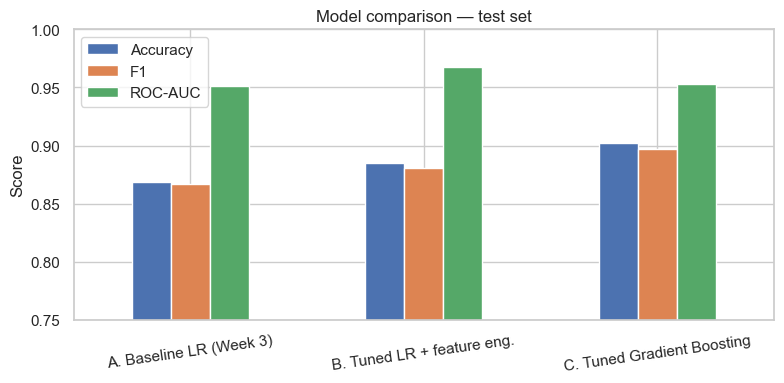

In [8]:
ax = results[["Accuracy","F1","ROC-AUC"]].plot(kind="bar", figsize=(8,4),
        rot=8, ylim=(0.75, 1.0))
ax.set_title("Model comparison — test set")
ax.set_ylabel("Score"); plt.tight_layout(); plt.show()

**Reading the table.** Feature engineering plus tuning lifts the logistic
regression from 0.951 to **0.968 test ROC-AUC** (CV-AUC 0.912 → 0.921), the
strongest and most stable result. Gradient boosting reaches the highest raw test
**accuracy (0.902)** but its cross-validated AUC (0.897) is *lower* than the tuned
LR — a sign it does not generalize better on only ~300 records. Recall on the
disease class stays at **0.929** across all models, which is the clinically
important property (a missed diagnosis is costlier than a false alarm).

### 5b. Confusion matrix and ROC for the recommended model (B)

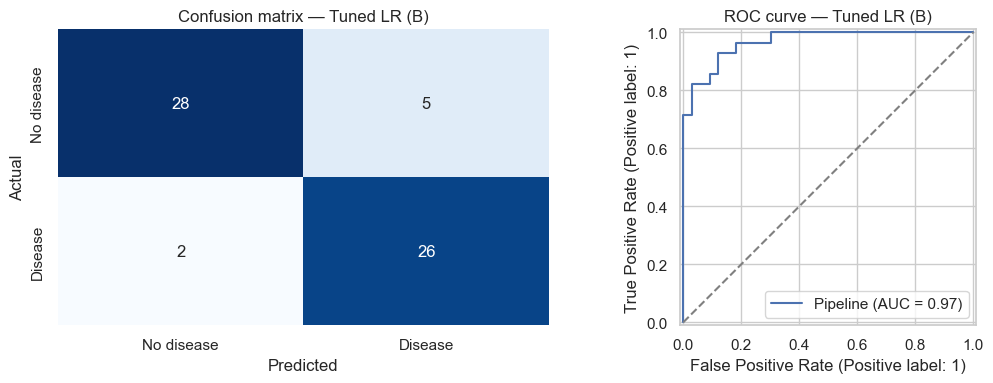

              precision    recall  f1-score   support

  No disease       0.93      0.85      0.89        33
     Disease       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
cm = confusion_matrix(y_test, model_B.predict(X_test))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax[0],
            xticklabels=["No disease","Disease"], yticklabels=["No disease","Disease"])
ax[0].set_title("Confusion matrix — Tuned LR (B)")
ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("Actual")
RocCurveDisplay.from_estimator(model_B, X_test, y_test, ax=ax[1])
ax[1].set_title("ROC curve — Tuned LR (B)"); ax[1].plot([0,1],[0,1],"--",c="gray")
plt.tight_layout(); plt.show()
print(classification_report(y_test, model_B.predict(X_test),
                            target_names=["No disease","Disease"]))

## 6. Explainability with SHAP
SHAP (SHapley Additive exPlanations) attributes each prediction to its input
features. We explain the gradient-boosting model with a `TreeExplainer`, giving
both a **global** ranking (mean absolute SHAP value) and a **local** explanation
for a single patient.

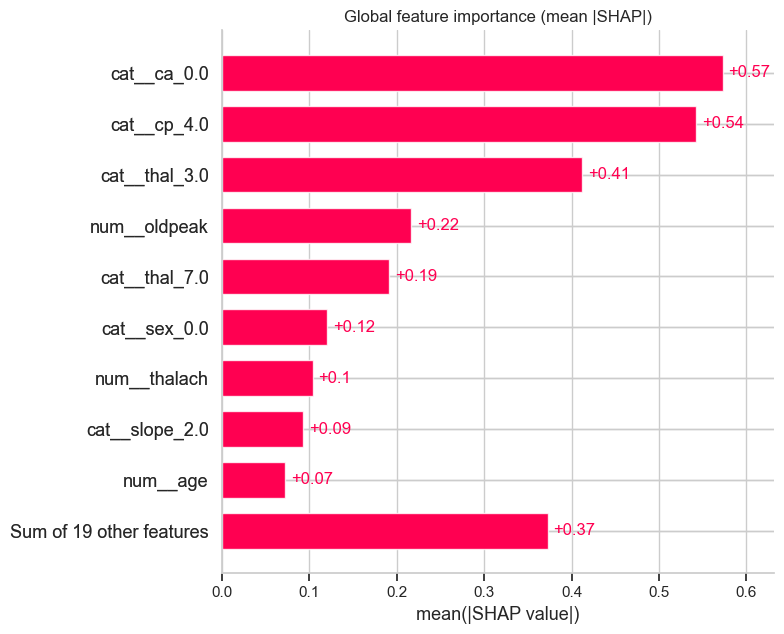

In [10]:
# Transform the test set and attach readable feature names
feat_names = model_C.named_steps["pre"].get_feature_names_out()
X_test_t = pd.DataFrame(model_C.named_steps["pre"].transform(X_test),
                        columns=feat_names, index=X_test.index)

explainer = shap.TreeExplainer(model_C.named_steps["clf"])
explanation = explainer(X_test_t)          # modern Explanation object

shap.plots.bar(explanation, max_display=10, show=False)
plt.title("Global feature importance (mean |SHAP|)"); plt.tight_layout(); plt.show()

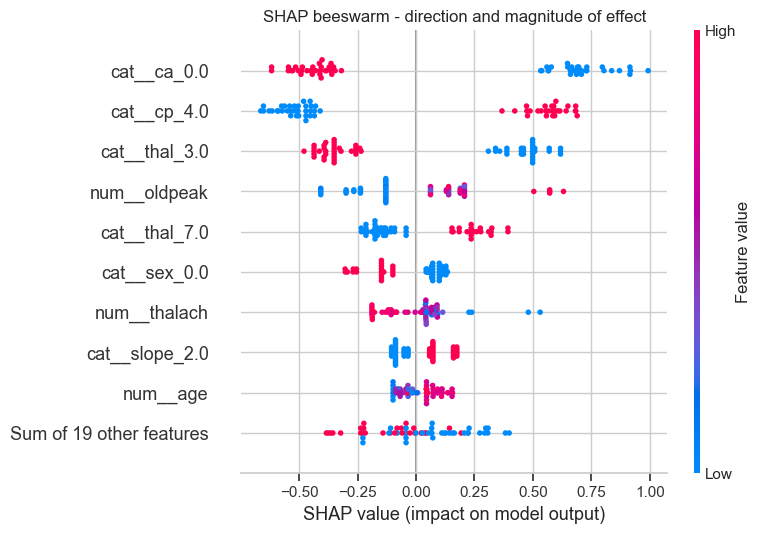

In [11]:
shap.plots.beeswarm(explanation, max_display=10, show=False)
plt.title("SHAP beeswarm - direction and magnitude of effect")
plt.tight_layout(); plt.show()

### 6b. Local explanation — one patient

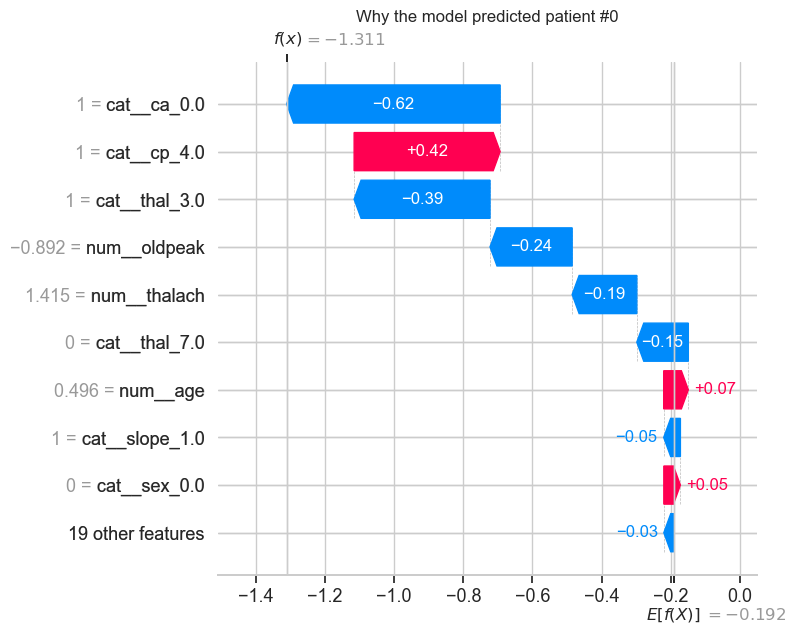

Predicted P(disease): 0.212 | Actual: 0


In [12]:
i = 0
shap.plots.waterfall(explanation[i], max_display=10, show=False)
plt.title(f"Why the model predicted patient #{i}"); plt.tight_layout(); plt.show()
print("Predicted P(disease):", round(model_C.predict_proba(X_test.iloc[[i]])[0,1], 3),
      "| Actual:", int(y_test.iloc[i]))

The top drivers — number of major vessels (`ca`), chest-pain type (`cp`),
thalassemia (`thal`), ST depression (`oldpeak`), and max heart rate (`thalach`) —
match established cardiac risk factors and agree with the logistic-regression
coefficients, a useful sanity check that the model learned clinically sensible
signal rather than noise.

## 7. Trade-offs: accuracy, efficiency, and fairness
### 7a. Fairness — performance across sex subgroups

In [13]:
fair = []
for s, label in [(0, "Female"), (1, "Male")]:
    mask = X_test["sex"] == s
    m = evaluate(model_B, X_test[mask], y_test[mask])
    m["n"] = int(mask.sum()); m["Positive rate"] = round(y_test[mask].mean(), 2)
    fair.append(pd.Series(m, name=label))
pd.DataFrame(fair)[["n","Positive rate","Accuracy","Recall","ROC-AUC"]].round(3)

,n,Positive rate,Accuracy,Recall,ROC-AUC
Female,20.0,0.35,0.950,0.857,1.000
Male,41.0,0.51,0.854,0.952,0.955


**Efficiency.** The tuned logistic regression trains in well under a second,
produces signed, directly interpretable coefficients, and is trivial to deploy on
free CPU — versus the gradient-boosting model, which needs an ensemble of trees for
a *lower* cross-validated AUC. On this dataset the simpler model is also the better
generalizer, so accuracy and efficiency point the same way.

**Fairness.** The dataset is ~68% male, and the model's behavior differs by sex:
accuracy is higher for the small female subgroup while recall is higher for males.
With only ~20 female test patients these estimates are noisy, but the disparity is
an ethical flag — the model should not be assumed equally reliable across groups,
and a deployed system would need subgroup monitoring and a larger, more
representative sample before any real use.

### Recommendation
The **tuned logistic regression with feature engineering (Model B)** is the
preferred model: it has the best cross-validated ROC-AUC, retains high recall, is
the most interpretable and efficient, and generalizes better than the heavier
gradient-boosting alternative.

## 8. Summary of findings
| Item | Result |
|---|---|
| Best model | Tuned Logistic Regression + feature engineering |
| Test ROC-AUC | 0.968 (up from 0.951 baseline) |
| CV ROC-AUC | 0.921 ± 0.019 (up from 0.912) |
| Test accuracy | 0.885 (up from 0.869) |
| Disease recall | 0.929 (unchanged, clinically prioritized) |
| Top predictors (SHAP) | ca, cp, thal, oldpeak, thalach |
| Ethical flags | sex imbalance; subgroup performance gap; educational use only |

Next steps: aggregate the Hungarian/Switzerland/VA cohorts for a larger, cross-site
test; add probability calibration and threshold tuning for recall; and log
experiments with Weights & Biases.